# $$Digit-Recognition-Project$$

We have a trained model
- We will bring in a handwritten image
- we will use the model to run inference on it

1. Upload image into notebook
2. Load the model
3. Pass image through the model

Libraries we could use:
- Python Imaging Library - PIL 
    - known as `Pillow`
    - used for image processing
    - open, resize, convert image formats
    - Open a .png and save it as .jpg or .webp
    - can convert an `RGB` color image to  `L` grayscale image
    - resize, rotate, crop
    - brightness, contrast, sharpness
- OpenCV - 

In [1]:
# 
import numpy as np
from PIL import Image, ImageOps

import tensorflow as tf

In [2]:
# load model
model = tf.keras.models.load_model('digit-recognition-model.keras')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

In [3]:
path = 'five_img.jpg'

img = Image.open(path) # pil object

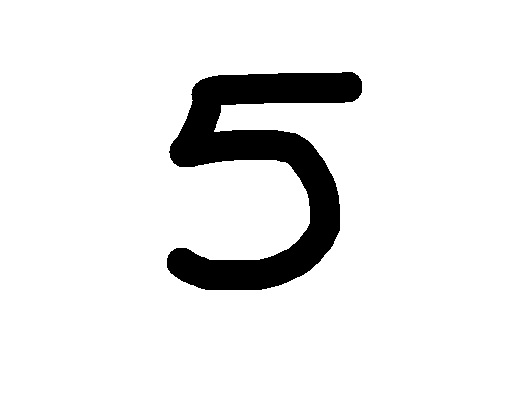

In [4]:
type(img)
img

- Neural Networks are very strict
- input should be of the exact shape, size, format, that the training data was
- otherwise bad predictions

In [5]:
# Resizing in PIL
img = img.resize((28,28))
img

In [6]:
# convert the PIL object into a numpy array
img_np = np.array(img)
img_np.shape # shape 28,28, 3     # 398, 513, 3

(28, 28, 3)

In [ ]:
# shape fix
img_np = img_np.reshape(1, 28, 28, 1)

img_np.shape

ValueError: cannot reshape array of size 2352 into shape (1,28,28,1)

In [10]:
# tensorflow model accepts inputs of certain shape
# batch, height, width, channels
# (1, 28, 28, 1)
model.predict(img)

ValueError: Unrecognized data type: x=<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=513x398 at 0x1C213C47080> (of type <class 'PIL.JpegImagePlugin.JpegImageFile'>)

In [8]:
print(f"{len(model.predict(img_np))}")

ValueError: Exception encountered when calling MaxPooling2D.call().

[1mNegative dimension size caused by subtracting 2 from 1 for '{{node sequential_1_1/max_pooling2d_2_1/MaxPool2d}} = MaxPool[T=DT_FLOAT, data_format="NHWC", explicit_paddings=[], ksize=[1, 2, 2, 1], padding="VALID", strides=[1, 2, 2, 1]](sequential_1_1/conv2d_2_1/Relu)' with input shapes: [28,26,1,32].[0m

Arguments received by MaxPooling2D.call():
  • inputs=tf.Tensor(shape=(28, 26, 1, 32), dtype=float32)

# Copilot betulkan

In [9]:
import numpy as np
from PIL import Image, ImageOps

import tensorflow as tf
# load model
model = tf.keras.models.load_model('digit-recognition-model.keras')
model.summary()  # shows the architecture of the loaded model

path = 'five_img.jpg'

img = Image.open(path) # pil object

# Resizing in PIL
img = img.resize((28,28))  # resize image to 28x28 pixels (MNIST-like size)
img  # just displays the PIL image object in some environments

# convert the PIL object into a numpy array
img_np = np.array(img)
img_np.shape # shape 28,28, 3     # original image had 398, 513, 3 (height, width, channels)

# shape fix
img_np = img_np.reshape(1, 28, 28, 1)  # reshape to match model input: batch=1, height=28, width=28, channels=1

img_np.shape  # now (1, 28, 28, 1)

# tensorflow model accepts inputs of certain shape
# batch, height, width, channels
# (1, 28, 28, 1)

# ⚠️ This line is incorrect: you are passing a PIL image instead of a numpy array
# model.predict(img)  # should be model.predict(img_np)

# run prediction on the reshaped numpy array
predictions = model.predict(img_np)

# predictions is usually a 2D array: (batch_size, num_classes)
# len(predictions) will give batch_size (here 1)
print(f"{len(predictions)}")  # prints 1 because you only passed one image

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

ValueError: cannot reshape array of size 2352 into shape (1,28,28,1)

In [11]:
import numpy as np
from PIL import Image, ImageOps

import tensorflow as tf
# load model
model = tf.keras.models.load_model('digit-recognition-model.keras')
model.summary()  # shows the architecture of the loaded model

path = 'five_img.jpg'

img = Image.open(path) # pil object

# Convert to grayscale (MNIST digits are single-channel)
img = img.convert('L')

# Resizing in PIL
img = img.resize((28,28))  # resize image to 28x28 pixels (MNIST-like size)
img  # just displays the PIL image object in some environments

# convert the PIL object into a numpy array
img_np = np.array(img)
img_np.shape # shape 28,28     # original image had 398, 513, 3 (height, width, channels)

# shape fix
img_np = img_np.reshape(1, 28, 28, 1)  # reshape to match model input: batch=1, height=28, width=28, channels=1

img_np.shape  # now (1, 28, 28, 1)

# tensorflow model accepts inputs of certain shape
# batch, height, width, channels
# (1, 28, 28, 1)

# run prediction on the reshaped numpy array
predictions = model.predict(img_np)

# predictions is usually a 2D array: (batch_size, num_classes)
# len(predictions) will give batch_size (here 1)
print(f"{len(predictions)}")  # prints 1 because you only passed one image

# To see the actual probabilities:
print(predictions)

# To see the predicted digit:
print(np.argmax(predictions))

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
9


In [12]:
import numpy as np
from PIL import Image, ImageOps

import tensorflow as tf
# load model
model = tf.keras.models.load_model('digit-recognition-model.keras')
model.summary()  # shows the architecture of the loaded model

path = 'Nombor_4.png'

img = Image.open(path) # pil object

# Convert to grayscale (MNIST digits are single-channel)
img = img.convert('L')

# Resizing in PIL
img = img.resize((28,28))  # resize image to 28x28 pixels (MNIST-like size)
img  # just displays the PIL image object in some environments

# convert the PIL object into a numpy array
img_np = np.array(img)
img_np.shape # shape 28,28     # original image had 398, 513, 3 (height, width, channels)

# shape fix
img_np = img_np.reshape(1, 28, 28, 1)  # reshape to match model input: batch=1, height=28, width=28, channels=1

img_np.shape  # now (1, 28, 28, 1)

# tensorflow model accepts inputs of certain shape
# batch, height, width, channels
# (1, 28, 28, 1)

# run prediction on the reshaped numpy array
predictions = model.predict(img_np)

# predictions is usually a 2D array: (batch_size, num_classes)
# len(predictions) will give batch_size (here 1)
print(f"{len(predictions)}")  # prints 1 because you only passed one image

# To see the actual probabilities:
print(predictions)

# To see the predicted digit:
print(np.argmax(predictions))

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
0


In [13]:
# Test nombor 4

import numpy as np
from PIL import Image, ImageOps

import tensorflow as tf
# load model
model = tf.keras.models.load_model('digit-recognition-model.keras')
model.summary()  # shows the architecture of the loaded model

path = 'Nombor_5.png'

img = Image.open(path) # pil object

# Convert to grayscale (MNIST digits are single-channel)
img = img.convert('L')

# Resizing in PIL
img = img.resize((28,28))  # resize image to 28x28 pixels (MNIST-like size)
img  # just displays the PIL image object in some environments

# convert the PIL object into a numpy array
img_np = np.array(img)
img_np.shape # shape 28,28     # original image had 398, 513, 3 (height, width, channels)

# shape fix
img_np = img_np.reshape(1, 28, 28, 1)  # reshape to match model input: batch=1, height=28, width=28, channels=1

img_np.shape  # now (1, 28, 28, 1)

# tensorflow model accepts inputs of certain shape
# batch, height, width, channels
# (1, 28, 28, 1)

# run prediction on the reshaped numpy array
predictions = model.predict(img_np)

# predictions is usually a 2D array: (batch_size, num_classes)
# len(predictions) will give batch_size (here 1)
print(f"{len(predictions)}")  # prints 1 because you only passed one image

# To see the actual probabilities:
print(predictions)

# To see the predicted digit:
print(np.argmax(predictions))

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1
[[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]
4
